# How to create your RADAR object

In [39]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import sys
import os

sys.path.append(os.path.abspath('../Pathfinder'))

from helper_functions import *
from radar_functions import *
from pathfinder import *
from attach_grounddata import *
from add_dataflashlog import *
from clicki_tool import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Load your data. We need an $n \times m$ radar echogram (*rx*) with the $n$ range bins reflected by a time-dimension axis (two-way traveltime aka *fasttime*) and a space-dimension axis (*range_air*). $m$ does not need a physical coordinate, but should reflect slowtime or distance.

Here we demostrate it based on UAV-mounted GPR data from GEORESEARCH (Siebenbrunner et al, 2025):

In [40]:
# Open the dataset
import segyio
with segyio.open('../Data/GEORESEARCH/3m_lidar_gpr_2.SGY', strict=False) as f:
    data = f.trace.raw[:]
    
# Extracting the important info

fasttime = np.linspace(0, 100, data.shape[1]) # 100 ns time window
fasttime_subset =  fasttime[70:-100]

data_subset = data[:, 70:-100].T

range_air = 0.299792458 * fasttime_subset / 2  * 100# should be in m then
def TWTT_to_depth(x, rho):
    return (x / 2  * np.sqrt(eps_r_ulaby(rho))/10)

range_snow = TWTT_to_depth(fasttime_subset, 320)

# For uncertainty quantification we need the radar bandwidth:
bandwidth = 0.7 * 1e9 # Hz

L, S = rpca_pcp_ialm(
            data_subset,
            sparsity_factor= .5 / np.sqrt(max(data_subset.shape)), # 1 is a value. --> 0.5 or 0.75 are probably more appropriate in most cases!
            max_iter=100,
            verbose=False,
            tol=1e-9,
        )
        

Create the RADAR object with minimal requirements satisified

In [42]:
# Create the object
from helper_functions import rdr

RADAR = rdr()
RADAR.rx = data_subset
RADAR.rx_rpca = S


RADAR.fasttime = fasttime_subset
RADAR.range_air = range_air
RADAR.range_snow = range_snow

RADAR.bandwidth = bandwidth
RADAR.dft = RADAR.fasttime[1] * 1e-9
# Here you could any other variables associated e.g. to the system slowtime such as GNSS coordinates, flightstate etc
# RADAR.GPS = 


Just set your desired path and filename to save it. Then you can load this in e.g. Notebooks/running_Pathfinder.ipynb.

In [43]:
path = '../Data/GEORESEARCH'
filename = 'your_RADAR_object.pkl'

# save the RADAR object
with open(os.path.join(path, filename), 'wb') as outp:
    pickle.dump(RADAR, outp, pickle.HIGHEST_PROTOCOL)

# Creating RADAR objects for the other systems

### AWI

In [44]:
from readgssi import readgssi

# path = '../Data/AWI/ANT_____039.DZT'
path = '/Users/torka/NORCE_T/Data/AWI_GPR/1011-1012/ANT_____039.DZT'

hdr, arrays, gps = readgssi.readgssi(
    infile=path,
    verbose=True,
)

marks = hdr['marks'].copy()
tst = arrays[0][:1550, :marks[-1]]

slowtime = np.linspace(0, hdr['sec'], arrays[0].shape[1])
slowtime = slowtime[:marks[-1]]  # limit to the last mark
samples_per_second = hdr['dzt_sps']

TWTT = 100 #where is this in the file?
fasttime = np.linspace(0, TWTT * 1e-10 , arrays[0].shape[0])  # convert to seconds (from ns)
fasttime = fasttime[:1550]

c = 299792458  # speed of light in m/s
range_air = fasttime * c / 2  # divide by 2 for two-way travel

eps_r = 1.55 #+- .1 from the papar
range_snow = range_air / np.sqrt(eps_r)


bandwidth = 0.25 * 1e9 # Hz

2025-09-29 16:38:55 - reading...
2025-09-29 16:38:55 - input file:         /Users/torka/NORCE_T/Data/AWI_GPR/1011-1012/ANT_____039.DZT
2025-09-29 16:38:55 - WARNING: no time zero specified for channel 0, defaulting to rh_zero value (0)
2025-09-29 16:38:55 - WARNING: no DZG file found for GPS input
2025-09-29 16:38:55 - WARNING: could not find DZX file to read metadata. Trying to read array for marks...
2025-09-29 16:38:55 - DZT marks read successfully. marks: 2
2025-09-29 16:38:55 -                             traces: [2212, 6608]
2025-09-29 16:38:55 - success. header values:
2025-09-29 16:38:55 - system:             SIR 3000 (system code 3)
2025-09-29 16:38:55 - antennas:           ['400MHz', None, None, None]
2025-09-29 16:38:55 - ant freqs. (MHz):   [400, None, None, None]
2025-09-29 16:38:55 - ant time zeros:     [0, None, None, None]
2025-09-29 16:38:55 - ant 0 center freq:  400 MHz
2025-09-29 16:38:55 - date created:       2006-10-12 11:28:18+00:00
2025-09-29 16:38:55 - date modi

In [45]:
rx = arrays[0][:, 2000:4000]

_, S = rpca_pcp_ialm(
            rx,
            sparsity_factor= .5 / np.sqrt(max(rx.shape)),
            max_iter=100,
            verbose=False
        )
section = S[:, 0:None].copy() * -1

In [46]:
# Create the object
from helper_functions import rdr

RADAR = rdr()
RADAR.rx = S

RADAR.fasttime = fasttime
RADAR.range_air = range_air
RADAR.range_snow = range_snow

RADAR.slowtime = slowtime
RADAR.bandwidth = bandwidth
RADAR.dft = RADAR.fasttime[1] * 1e-9

In [47]:
path = '../Data/AWI'
filename = 'your_RADAR_object.pkl'

# save the RADAR object
with open(os.path.join(path, filename), 'wb') as outp:
    pickle.dump(RADAR, outp, pickle.HIGHEST_PROTOCOL)

### Kiwi

In [57]:
files = sorted(os.listdir('../Data/Kiwi'))

if 'data' in locals():
    del data
    
for i, f in enumerate(files):
    # print(f)
    if f.endswith('.txt') and f.startswith('signev'):
        d = np.loadtxt(os.path.join('../Data/Kiwi', f))
        # print(d.shape)
        data = np.concatenate([data, d], axis=0) if 'data' in locals() else d

data = data.T
print(data.shape)
range_axis = np.loadtxt('../Data/Kiwi/range.txt')


transformer = Transformer.from_crs("epsg:4326", "epsg:6932", always_xy=True)

df_gps = pd.read_csv('../Data/Kiwi/geotagged_interp.txt')
df_gps['EASE_x'], df_gps['EASE_y'] = transformer.transform(df_gps[' GPS_lon'].values, df_gps[' GPS_lat'].values)
df_gps['dist'] = np.sqrt((df_gps['EASE_x'] - df_gps.loc[0, 'EASE_x'])**2 + (df_gps['EASE_y'] - df_gps.loc[0, 'EASE_y'])**2)


bandwidth = 4 * 1e9 # Hz


y_startind = 80
y_endind = 250

range_axis = range_axis[y_startind:y_endind]
data = data[y_startind:y_endind]

(3148, 3500)


In [58]:
_, S = rpca_pcp_ialm(
                data,
                sparsity_factor= .25 / np.sqrt(max(data.shape)), # 1 is a value. --> 0.5 or 0.75 are probably more appropriate in most cases!
                max_iter=100,
                verbose=False
            )

section = S[:, 0:None].copy()

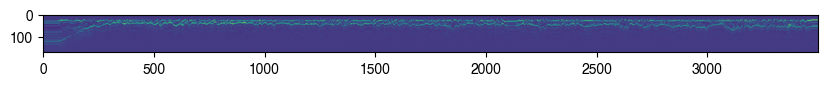

In [59]:
fig, ax = plt.subplots(1,1, figsize=(10,5))

ax.imshow(S)

In [60]:
# Create the object
from helper_functions import rdr

RADAR = rdr()
RADAR.rx = data
RADAR.rx_rpca = S

RADAR.range_air = range_axis

RADAR.bandwidth = bandwidth

RADAR.GPS_lat = df_gps[' GPS_lat'].values
RADAR.GPS_lon = df_gps[' GPS_lon'].values

RADAR.EASE2_x = df_gps['EASE_x'].values
RADAR.EASE2_y = df_gps['EASE_y'].values
RADAR.dist = df_gps['dist'].values


In [61]:
path = '../Data/Kiwi'
filename = 'your_RADAR_object.pkl'

# save the RADAR object
with open(os.path.join(path, filename), 'wb') as outp:
    pickle.dump(RADAR, outp, pickle.HIGHEST_PROTOCOL)